# 04. STL 기반 대여소 수요 이상 탐지
상위 대여소의 시간대별 수요를 STL로 분해해 구조적 패턴과 실제 이상을 구분합니다.


## 분석 전략

**목표**: 운영적으로 대응 가능한 수요 급증·급감 시점을 찾는다.

| 단계 | 내용 | 핵심 산출물 |
|---|---|---|
| 1 | 시간대별 대여량 데이터 로드 | 상위 50개 대여소 선정 |
| 2 | STL 분해로 추세·계절성 제거 | 대여소별 이상 시간대 |
| 3 | 이상 패턴 분류 및 운영 해석 | 재배치 우선 대여소와 시간대 |

이 노트북은 `Isolation Forest` 기반 트립 이상치 탐지 대신, **대여소 운영 관점에서 바로 활용 가능한 시계열 이상 탐지** 하나에 집중한다.


In [1]:
import sys
import warnings

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.tsa.seasonal import STL

for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

from src.data_loader import load_processed

print("✅ 준비 완료")


Matplotlib is building the font cache; this may take a moment.


✅ 준비 완료


## 1. 데이터 로드

분석에는 대여소별 시간대 대여량 집계 데이터(`station_hourly_demand`)를 사용한다. 먼저 전체 기간과 상위 대여소 분포를 확인해, STL을 적용할 분석 대상을 정한다.


📂 Loaded station_hourly_demand.parquet → shape: (3835657, 5)


✅ 전체 시간대 레코드: 3,835,657건
✅ 기간: 2025-10-01 00:00:00 ~ 2025-12-31 23:00:00
✅ 전체 대여소 수: 2,791개
✅ 분석 대상: 상위 50개 대여소

[상위 10개 대여소 누적 대여량]
stn_id
ST-2031    38539.0
ST-891     26800.0
ST-2045    26155.0
ST-1718    25913.0
ST-413     20670.0
ST-1065    20603.0
ST-3388    18421.0
ST-1681    17700.0
ST-522     16031.0
ST-3311    15373.0


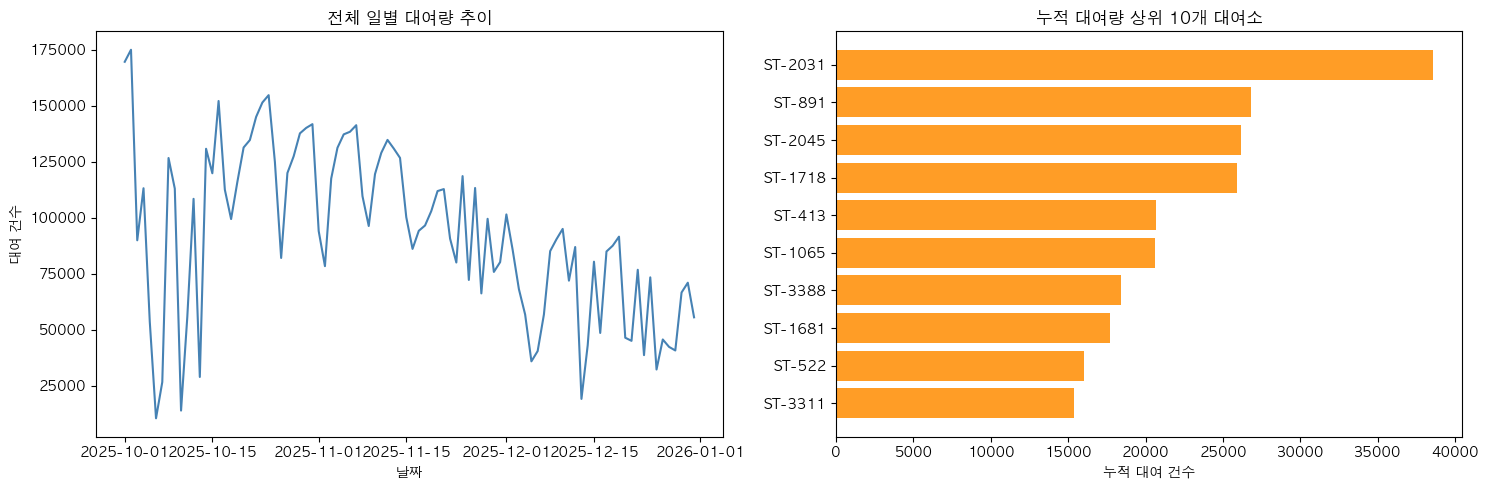

In [2]:
hourly = load_processed("station_hourly_demand").copy()
hourly["datetime_hour"] = pd.to_datetime(hourly["datetime_hour"])

station_totals = hourly.groupby("stn_id")["rent_count"].sum().sort_values(ascending=False)
top50_stns = station_totals.head(50).index.tolist()
daily_total = hourly.groupby(hourly["datetime_hour"].dt.date)["rent_count"].sum()

print(f"✅ 전체 시간대 레코드: {len(hourly):,}건")
print(f"✅ 기간: {hourly['datetime_hour'].min()} ~ {hourly['datetime_hour'].max()}")
print(f"✅ 전체 대여소 수: {hourly['stn_id'].nunique():,}개")
print(f"✅ 분석 대상: 상위 50개 대여소")
print("\n[상위 10개 대여소 누적 대여량]")
print(station_totals.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

daily_total.plot(ax=axes[0], color="steelblue", linewidth=1.5)
axes[0].set_title("전체 일별 대여량 추이")
axes[0].set_xlabel("날짜")
axes[0].set_ylabel("대여 건수")

top10 = station_totals.head(10).sort_values()
axes[1].barh(top10.index.astype(str), top10.values, color="darkorange", alpha=0.85)
axes[1].set_title("누적 대여량 상위 10개 대여소")
axes[1].set_xlabel("누적 대여 건수")

plt.tight_layout()
plt.savefig("../reports/figures/stl_overview.png", dpi=150)
plt.show()


## 2. STL 기반 수요 이상 탐지

각 대여소의 시간대별 대여량 시계열에 `STL(period=24, robust=True)`을 적용해 하루 주기의 계절성을 분리한다. 이후 잔차의 절댓값이 `3σ`를 넘는 시점을 이상으로 정의하고, 이를 운영적으로 해석 가능한 패턴으로 분류한다.

패턴 분류 기준은 다음과 같다.
- `공휴일`: 법정 공휴일에 발생한 이상
- `주말`: 주말 수요 구조 차이로 발생한 이상
- `평일 저녁 급증`: 17~19시의 양의 잔차
- `평일 출근 급감`: 08시의 음의 잔차
- 그 외는 `기타 급증` 또는 `기타 급감`


분석 스테이션: 50개
전체 STL 이상 시간대: 2,776개

=== 패턴별 분류 ===
pattern
주말          1275
기타 급증        522
평일 저녁 급증     499
기타 급감        344
공휴일          116
평일 출근 급감      20

=== 운영 우선순위: 평일 저녁 급증 상위 10개 대여소 ===
stn_id
ST-18      25
ST-1064    25
ST-3311    21
ST-1063    17
ST-1709    17
ST-2871    16
ST-3094    16
ST-522     15
ST-3163    15
ST-2033    14

=== 이상 집중 날짜 Top 10 ===
date
2025-10-08    154
2025-10-16    113
2025-10-25    105
2025-11-01     97
2025-11-09     96
2025-10-10     93
2025-10-14     90
2025-11-02     87
2025-10-13     83
2025-10-19     81


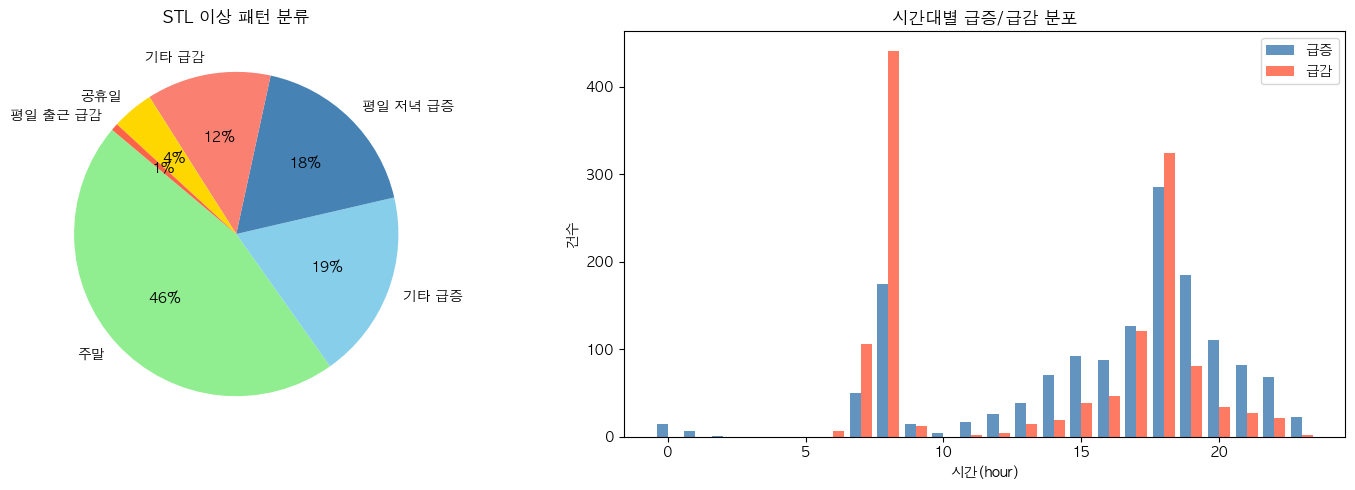

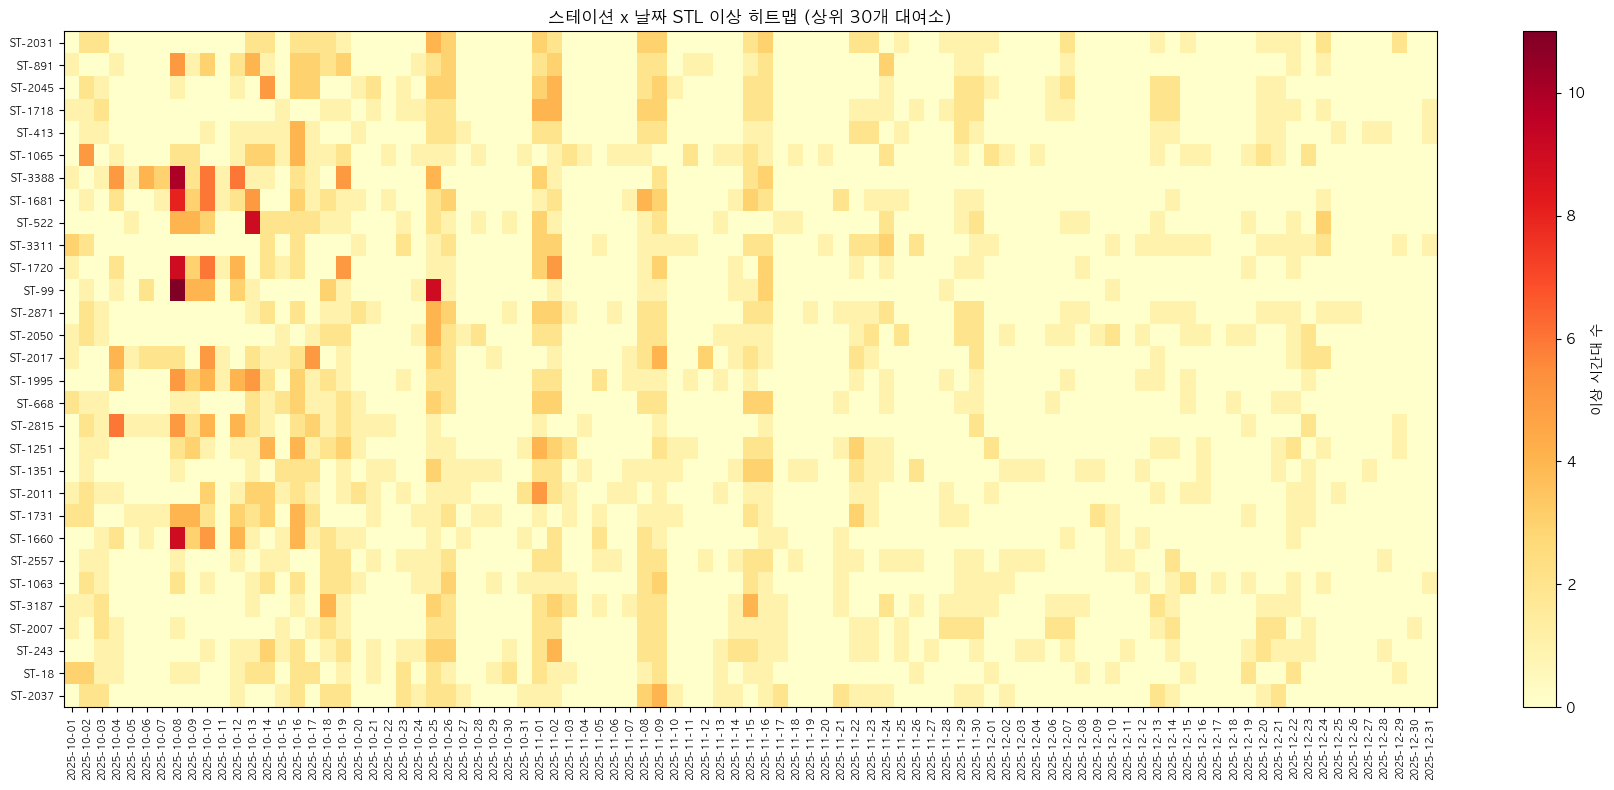

In [3]:
HOLIDAYS_SET = set(pd.to_datetime(["2025-10-03", "2025-10-09", "2025-12-25"]))


def classify_stl(row):
    dt = row["datetime"]
    date = dt.normalize()
    hour = dt.hour
    dow = dt.dayofweek
    if date in HOLIDAYS_SET:
        return "공휴일"
    if dow >= 5:
        return "주말"
    if hour == 8 and row["resid"] < 0:
        return "평일 출근 급감"
    if 17 <= hour <= 19 and row["resid"] > 0:
        return "평일 저녁 급증"
    if row["resid"] < 0:
        return "기타 급감"
    return "기타 급증"


all_stl_records = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for stn_id in top50_stns:
        stn_ts = (
            hourly[hourly["stn_id"] == stn_id]
            .set_index("datetime_hour")["rent_count"]
            .asfreq("h")
            .fillna(0)
        )
        if len(stn_ts) < 48:
            continue

        result = STL(stn_ts, period=24, robust=True).fit()
        resid_std = result.resid.std()
        if resid_std == 0:
            continue

        mask = np.abs(result.resid) > 3 * resid_std
        for dt, resid_val in result.resid[mask].items():
            all_stl_records.append({
                "stn_id": stn_id,
                "datetime": dt,
                "resid": resid_val,
            })

stl_all = pd.DataFrame(all_stl_records)
stl_all["pattern"] = stl_all.apply(classify_stl, axis=1)
stl_all["direction"] = np.where(stl_all["resid"] > 0, "급증", "급감")
stl_all["date"] = stl_all["datetime"].dt.date
stl_all["hour"] = stl_all["datetime"].dt.hour

pattern_counts = stl_all["pattern"].value_counts()
hour_dir = stl_all.groupby("hour")["direction"].value_counts().unstack(fill_value=0)
priority_stns = stl_all[stl_all["pattern"] == "평일 저녁 급증"]["stn_id"].value_counts().head(10)
top_dates = stl_all["date"].value_counts().head(10)

print(f"분석 스테이션: {len(top50_stns)}개")
print(f"전체 STL 이상 시간대: {len(stl_all):,}개")
print("\n=== 패턴별 분류 ===")
print(pattern_counts.to_string())
print("\n=== 운영 우선순위: 평일 저녁 급증 상위 10개 대여소 ===")
print(priority_stns.to_string())
print("\n=== 이상 집중 날짜 Top 10 ===")
print(top_dates.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = {
    "공휴일": "gold",
    "주말": "lightgreen",
    "평일 출근 급감": "tomato",
    "평일 저녁 급증": "steelblue",
    "기타 급감": "salmon",
    "기타 급증": "skyblue",
}
colors_pie = [palette.get(name, "gray") for name in pattern_counts.index]
axes[0].pie(pattern_counts.values, labels=pattern_counts.index, autopct="%1.0f%%", colors=colors_pie, startangle=140)
axes[0].set_title("STL 이상 패턴 분류")

for label, offset, color in [("급증", -0.2, "steelblue"), ("급감", 0.2, "tomato")]:
    if label not in hour_dir.columns:
        hour_dir[label] = 0
    axes[1].bar(hour_dir.index + offset, hour_dir[label], width=0.4, color=color, alpha=0.85, label=label)
axes[1].set_title("시간대별 급증/급감 분포")
axes[1].set_xlabel("시간(hour)")
axes[1].set_ylabel("건수")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/stl_pattern_calendar.png", dpi=150)
plt.show()

pivot = stl_all.groupby(["stn_id", "date"]).size().unstack(fill_value=0)
pivot_plot = pivot.reindex(station_totals.head(30).index).fillna(0)

fig, ax = plt.subplots(figsize=(18, 8))
im = ax.imshow(pivot_plot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(range(len(pivot_plot)))
ax.set_yticklabels(pivot_plot.index.astype(str), fontsize=7)
ax.set_xticks(range(len(pivot_plot.columns)))
ax.set_xticklabels([str(d) for d in pivot_plot.columns], rotation=90, fontsize=7)
ax.set_title("스테이션 x 날짜 STL 이상 히트맵 (상위 30개 대여소)")
plt.colorbar(im, ax=ax, label="이상 시간대 수")
plt.tight_layout()
plt.savefig("../reports/figures/stl_station_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. 운영 해석

분석 결과 주말 이상은 상당 부분이 **구조적 수요 차이**에 가깝고, 실제 운영 대응 가치가 큰 패턴은 **평일 17~19시 급증**이다. 따라서 반복적으로 저녁 급증이 나타나는 대여소를 중심으로 `17시 이전 재배치` 규칙을 설계하는 것이 가장 실용적이다.
